# **DeepFace - Age, Gender, Expression, Headpose and Recognition**

---


In this lesson, we use the **DeepFace API for Age, Gender, Expression Facial and Recognition. We even use the headpose library to obtain head direction/tilt**. DeepFace is an easy to use python module that provides access to several Facial Detection and Recognition models. It's very simple to use to let's dive in.

1. Install the necessary modules and download our files
2. Demonstrate facial landmarks
3. Obtain Age, Gender, Emotional Expression and Ethnicity using DeepFace
4. Perform Facial Similarity
5. Perform Facial Recognition


**NOTE** Change to High-RAM setting.


## **1. Install the necessary modules and download our files**

In [1]:
!pip install deepface
!pip install dlib

  Using cached dlib-20.0.0.tar.gz (3.3 MB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
  Created wheel for dlib: filename=dlib-20.0.0-cp313-cp313-win_amd64.whl size=2921999 sha256=95a9bf3484145a81cf1c74eddde9674e52b9723e82845444707dc48815b15343
  Stored in directory: c:\users\gabriel\appdata\local\pip\cache\wheels\d4\0d\ef\354663d702c37ab4b234126cfc6b61cfb36eda5ba193613a2c
Successfully built dlib


#### **Define our imshow function**

In [1]:
# Some imports and our image viewing function
import dlib
import tarfile
import cv2
import numpy as np
from matplotlib import pyplot as plt

# Define our imshow function 
def imshow(title = "Image", image = None, size = 6):
    w, h = image.shape[0], image.shape[1]
    aspect_ratio = w/h
    plt.figure(figsize=(size * aspect_ratio,size))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.show()

In [3]:
# Download facial landmarks
#https://dlib.net/face_landmark_detection.py.html

## **2. Demonstrate facial landmarks**

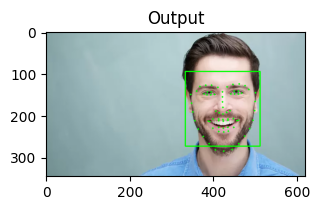

In [2]:
from imutils import face_utils

p = "shape_predictor_68_face_landmarks.dat"
detector = dlib.get_frontal_face_detector()
predictor = dlib.shape_predictor(p)

image = cv2.imread('test.webp')
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    
# Get faces 
rects = detector(gray, 0)

# For each detected face, find the landmark.
for (i, rect) in enumerate(rects):
    # Make the prediction and transfom it to numpy array
    shape = predictor(gray, rect)
    shape = face_utils.shape_to_np(shape)
    (x, y, w, h) = face_utils.rect_to_bb(rect)
    cv2.rectangle(image, (x, y), (x + w, y + h), (0, 255, 0), 2)
    # Draw on our image, all the finded cordinate points (x,y) 
    for (x, y) in shape:
        cv2.circle(image, (x, y), 2, (0, 255, 0), -1)

# Show the image
imshow("Output", image)

## **3. Obtain Age, Gender, Emotional Expression and Ethnicity using DeepFace**


https://github.com/serengil/deepface_models/releases/ 

Download dos modelos

Mover para a pasta de pesos do deepface. Por exemplo em: C:\Users\Gabriel\.deepface\weights

In [10]:
from deepface import DeepFace

obj = DeepFace.analyze(img_path =  "lfw_funneled/Duda/Duda2.jpeg", actions = ['age', 'gender', 'race', 'emotion'])

print(f"{obj[0]["age"]} years old {obj[0]["dominant_race"]}, {obj[0]["dominant_emotion"]} , {obj[0]["gender"]}")

Action: emotion: 100%|██████████| 4/4 [00:00<00:00, 11.74it/s]

29 years old white, neutral , {'Woman': np.float32(98.740616), 'Man': np.float32(1.2593803)}


Action: emotion: 100%|██████████| 4/4 [00:00<00:00, 10.39it/s]


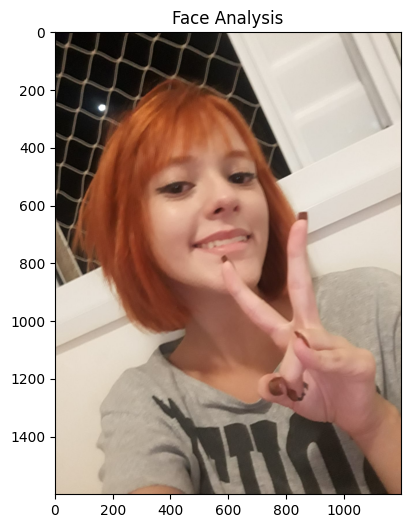

[   {   'age': 29,
        'dominant_emotion': 'neutral',
        'dominant_gender': 'Woman',
        'dominant_race': 'white',
        'emotion': {   'angry': np.float32(0.0006682016),
                       'disgust': np.float32(5.3864955e-08),
                       'fear': np.float32(0.06338714),
                       'happy': np.float32(2.079007),
                       'neutral': np.float32(92.61367),
                       'sad': np.float32(5.243141),
                       'surprise': np.float32(0.00012563064)},
        'face_confidence': 0.97,
        'gender': {   'Man': np.float32(1.2593803),
                      'Woman': np.float32(98.740616)},
        'race': {   'asian': np.float32(26.876554),
                    'black': np.float32(0.09178429),
                    'indian': np.float32(0.34509584),
                    'latino hispanic': np.float32(10.511714),
                    'middle eastern': np.float32(4.0191283),
                    'white': np.float32(58.155727)}

In [32]:
from deepface import DeepFace
import pprint

img_path = "lfw_funneled/Duda/Duda2.jpeg"
image = cv2.imread(img_path)

obj = DeepFace.analyze(img_path = img_path,
                       actions = ['age', 'gender', 'race', 'emotion'])
imshow("Face Analysis", image)
pp = pprint.PrettyPrinter(indent=4)
pp.pprint(obj)

#### **Create a simple function to display our results on the image**

In [17]:
import cv2

def drawFace(img_path, obj):
  image = cv2.imread(img_path)
  x = obj['region']['x'] 
  y = obj['region']['y'] 
  h = obj['region']['h'] 
  w = obj['region']['w'] 
  age = obj['age']
  gender = obj['gender']
  gender = 'F' if gender == 'Woman' else 'M'
  dominant_emotion = obj['dominant_emotion']
  dominant_race = obj['dominant_race']
  dominant_emotion = obj['dominant_emotion']
  description = f'{age}{gender} - {dominant_emotion}'
  cv2.rectangle(image, (x, y), (x+w, y+h), (0, 255, 0), 2)
  cv2.putText(image, description, (x,y-10) , cv2.FONT_HERSHEY_PLAIN,2, (0,255,0), 3)
  cv2.putText(image, dominant_race, (x,y+h+30) , cv2.FONT_HERSHEY_PLAIN,2, (0,255,0), 3)
  imshow("Face Analysis", image)

#### **Test on another image**

Action: emotion: 100%|██████████| 4/4 [00:00<00:00, 11.12it/s]


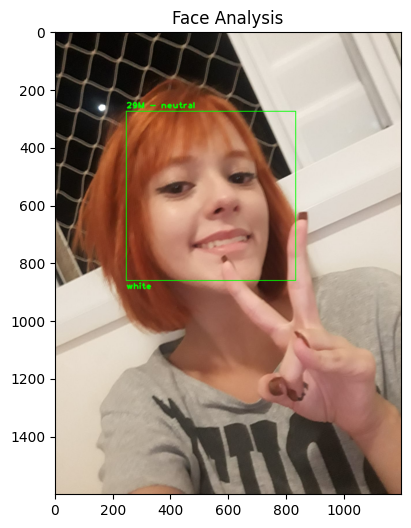

[ { 'age': 29,
    'dominant_emotion': 'neutral',
    'dominant_gender': 'Woman',
    'dominant_race': 'white',
    'emotion': { 'angry': np.float32(0.0006682016),
                 'disgust': np.float32(5.3864955e-08),
                 'fear': np.float32(0.06338714),
                 'happy': np.float32(2.079007),
                 'neutral': np.float32(92.61367),
                 'sad': np.float32(5.243141),
                 'surprise': np.float32(0.00012563064)},
    'face_confidence': 0.97,
    'gender': {'Man': np.float32(1.2593803), 'Woman': np.float32(98.740616)},
    'race': { 'asian': np.float32(26.876554),
              'black': np.float32(0.09178429),
              'indian': np.float32(0.34509584),
              'latino hispanic': np.float32(10.511714),
              'middle eastern': np.float32(4.0191283),
              'white': np.float32(58.155727)},
    'region': { 'h': 586,
                'left_eye': (631, 506),
                'right_eye': (413, 534),
                'w

In [33]:
from deepface import DeepFace
import pprint

img_path = "lfw_funneled/Duda/Duda2.jpeg"
image = cv2.imread(img_path)
obj = DeepFace.analyze(img_path = img_path, actions = ['age', 'gender', 'race', 'emotion'])
drawFace(img_path, obj[0])
pp = pprint.PrettyPrinter(indent=2)
pp.pprint(obj)

#### **Change backends of face detection**

Action: emotion: 100%|██████████| 4/4 [00:00<00:00, 10.66it/s]


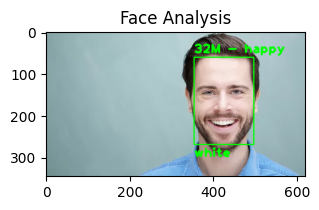

[   {   'age': 32,
        'dominant_emotion': 'happy',
        'dominant_gender': 'Man',
        'dominant_race': 'white',
        'emotion': {   'angry': np.float32(3.670332e-07),
                       'disgust': np.float32(1.9643009e-16),
                       'fear': np.float32(1.5660574e-11),
                       'happy': np.float32(99.99822),
                       'neutral': np.float32(0.0017746316),
                       'sad': np.float32(3.3604627e-07),
                       'surprise': np.float32(9.857389e-08)},
        'face_confidence': 0.98,
        'gender': {   'Man': np.float32(99.9997),
                      'Woman': np.float32(0.00029993456)},
        'race': {   'asian': np.float32(3.500616e-08),
                    'black': np.float32(3.6018837e-09),
                    'indian': np.float32(6.0002293e-07),
                    'latino hispanic': np.float32(0.028894586),
                    'middle eastern': np.float32(0.044049703),
                    'white': 

In [26]:
from deepface import DeepFace

# backends = ['opencv', 'ssd', 'dlib', 'mtcnn', 'retinaface']

img_path = "test.webp"
image = cv2.imread(img_path)
obj = DeepFace.analyze(img_path = "test.webp", actions = ['age', 'gender', 'race', 'emotion'], detector_backend = 'mtcnn')
drawFace(img_path, obj[0])
pp = pprint.PrettyPrinter(indent=4)
pp.pprint(obj)

## **4. Perform Facial Similarity**

In [29]:
result  = DeepFace.verify("lfw_funneled/Emma_Watson/Emma_Watson_0001.jpg", "lfw_funneled/Duda/Duda2.jpeg")
print("Is verified: ", result["verified"])
result

Is verified:  False


{'verified': False,
 'distance': 0.822934,
 'threshold': 0.68,
 'confidence': 6.65,
 'model': 'VGG-Face',
 'detector_backend': 'opencv',
 'similarity_metric': 'cosine',
 'facial_areas': {'img1': {'x': 70,
   'y': 71,
   'w': 117,
   'h': 117,
   'left_eye': (149, 116),
   'right_eye': (101, 115)},
  'img2': {'x': 246,
   'y': 274,
   'w': 586,
   'h': 586,
   'left_eye': (631, 506),
   'right_eye': (413, 534)}},
 'time': 0.43}

### **We can even use different Distance Metrics**

In [30]:
#metrics = ["cosine", "euclidean", "euclidean_l2"]

result  = DeepFace.verify("lfw_funneled/Emma_Watson/Emma_Watson_0001.jpg", "lfw_funneled/Duda/Duda2.jpeg", distance_metric = 'euclidean')
print("Is verified: ", result["verified"])
result

Is verified:  False


{'verified': False,
 'distance': 1.282914,
 'threshold': 1.17,
 'confidence': 7.25,
 'model': 'VGG-Face',
 'detector_backend': 'opencv',
 'similarity_metric': 'euclidean',
 'facial_areas': {'img1': {'x': 70,
   'y': 71,
   'w': 117,
   'h': 117,
   'left_eye': (149, 116),
   'right_eye': (101, 115)},
  'img2': {'x': 246,
   'y': 274,
   'w': 586,
   'h': 586,
   'left_eye': (631, 506),
   'right_eye': (413, 534)}},
 'time': 0.42}

In [31]:
#metrics = ["cosine", "euclidean", "euclidean_l2"]

result  = DeepFace.verify("lfw_funneled/Emma_Watson/Emma_Watson_0001.jpg", "lfw_funneled/Duda/Duda2.jpeg", distance_metric = 'euclidean_l2')
print("Is verified: ", result["verified"])
result

Is verified:  False


{'verified': False,
 'distance': 1.282914,
 'threshold': 1.17,
 'confidence': 7.25,
 'model': 'VGG-Face',
 'detector_backend': 'opencv',
 'similarity_metric': 'euclidean_l2',
 'facial_areas': {'img1': {'x': 70,
   'y': 71,
   'w': 117,
   'h': 117,
   'left_eye': (149, 116),
   'right_eye': (101, 115)},
  'img2': {'x': 246,
   'y': 274,
   'w': 586,
   'h': 586,
   'left_eye': (631, 506),
   'right_eye': (413, 534)}},
 'time': 0.45}

### **Baixe novamente outros modelos do link anterior para testar**

## **5. Perform Facial Recognition**

In [38]:
from deepface import DeepFace
import pandas as pd

df = DeepFace.find(img_path = "lfw_funneled/Emma_Watson/Emma_Watson_0001.jpg", db_path = './lfw_funneled/', detector_backend = 'ssd')
df

26-03-10 21:07:02 - Found 13236 newly added image(s), 0 removed image(s), 0 replaced image(s).


Finding representations:   0%|          | 0/13236 [00:00<?, ?it/s]

26-03-10 21:07:02 - 🔗 deploy.prototxt will be downloaded from https://github.com/opencv/opencv/raw/3.4.0/samples/dnn/face_detector/deploy.prototxt to C:\Users\Gabriel\.deepface\weights\deploy.prototxt...


Downloading...
From: https://github.com/opencv/opencv/raw/3.4.0/samples/dnn/face_detector/deploy.prototxt
To: C:\Users\Gabriel\.deepface\weights\deploy.prototxt
28.1kB [00:00, 44.6MB/s]                   


26-03-10 21:07:03 - 🔗 res10_300x300_ssd_iter_140000.caffemodel will be downloaded from https://github.com/opencv/opencv_3rdparty/raw/dnn_samples_face_detector_20170830/res10_300x300_ssd_iter_140000.caffemodel to C:\Users\Gabriel\.deepface\weights\res10_300x300_ssd_iter_140000.caffemodel...


...

Finding representations:  70%|███████   | 9271/13236 [22:56<07:50,  8.42it/s]

26-03-10 21:29:58 - 🔴 Exception while extracting faces from ./lfw_funneled/George_W_Bush\George_W_Bush_0166.jpg: Face could not be detected in ./lfw_funneled/George_W_Bush\George_W_Bush_0166.jpg.Please confirm that the picture is a face photo or consider to set enforce_detection param to False.


Finding representations: 100%|██████████| 13236/13236 [33:39<00:00,  6.56it/s]


26-03-10 21:40:46 - There are now 13906 representations in ds_model_vggface_detector_ssd_aligned_normalization_base_expand_0.pkl
26-03-10 21:40:46 - Searching lfw_funneled/Emma_Watson/Emma_Watson_0001.jpg in 13906 length datastore
26-03-10 21:40:53 - find function duration 2125.8795733451843 seconds


[                                            identity  \
 0    ./lfw_funneled/Emma_Watson\Emma_Watson_0001.jpg   
 1    ./lfw_funneled/Emma_Watson\Emma_Watson_0004.jpg   
 2    ./lfw_funneled/Emma_Watson\Emma_Watson_0003.jpg   
 3    ./lfw_funneled/Emma_Watson\Emma_Watson_0002.jpg   
 4    ./lfw_funneled/Emma_Watson\Emma_Watson_0005.jpg   
 5  ./lfw_funneled/Elizabeth_Smart\Elizabeth_Smart...   
 
                                        hash  target_x  target_y  target_w  \
 0  73ef86d178b6990395d34d94163f679e4523bd92        71        58       104   
 1  2dfc633262f4b8712f68901995aa440e7b26ec8f        78        51       105   
 2  d2add9650eee2a3f4e17bdb2e5d7373b619f0a6e        76        53        97   
 3  9ac9e64b8d1b53d2fd5ba79c189e3834b073dd2e        73        53       108   
 4  4041fb37d9e0dcd5aec1889a9918ba787ddacf0d        75        55       103   
 5  506cbf692e1d300cb8141bdbbde461c9423e0047        70        45       103   
 
    target_h  threshold  source_x  source_y  source

## **We can even try a few different models**

In [43]:
from deepface import DeepFace
import pandas as pd

dfs = []
models = ["VGG-Face", "Facenet", "OpenFace", "DeepFace", "DeepID", "ArcFace", "Dlib"]

for model in models:
   df = DeepFace.find(img_path = "lfw_funneled/Emma_Watson/Emma_Watson_0001.jpg", db_path = './lfw_funneled/', model_name = model,  detector_backend = 'ssd')
   df[0]['model'] = model
   dfs.append(df)

pd.concat(dfs)

26-03-10 23:43:02 - Searching lfw_funneled/Emma_Watson/Emma_Watson_0001.jpg in 13906 length datastore
26-03-10 23:43:07 - find function duration 8.855284690856934 seconds
26-03-10 23:43:09 - Found 13236 newly added image(s), 0 removed image(s), 0 replaced image(s).


Finding representations:   0%|          | 46/13236 [00:11<55:15,  3.98it/s]  


KeyboardInterrupt: 

Here's a great tutorial on building a MongoDB based system for facial recognition https://sefiks.com/2021/01/22/deep-face-recognition-with-mongodb/